# BMW Vehicle Production & Dealership Sales Analysis

---

## 📊 Project Overview

This analysis examines **BMW vehicle sales data** across global dealerships to understand the key factors driving unit sales and build a predictive regression model.- **Categorical**: `country`, `model`, `segment`, `engine_type`

- **Continuous**: `price_usd`, `marketing_spend_usd`, `year`, `dealership_count`

### 🎯 Objectives### 📌 Key Predictors

1. **Exploratory Data Analysis (EDA)** - Understand data structure, distributions, and relationships

2. **Data Preprocessing** - Clean data, encode categories, prepare for modeling- **units_sold** - Number of BMW units sold at each dealership

3. **Collinearity Assessment** - Check VIF and correlation to identify multicollinearity issues### 📈 Target Variable

4. **Regression Modeling** - Build OLS regression model with all predictors

5. **Model Evaluation** - Calculate performance metrics (R², RMSE, MAE)6. **Feature Analysis** - Identify which predictors most strongly influence sales

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## 1️⃣ EXPLORATORY DATA ANALYSIS (EDA)

### Load & Inspect Data
First, load the CSV file and examine the structure, shape, and data types

In [247]:
df = pd.read_csv('bmw_global_sales_dataset.csv')
df

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024,10,UK,i4,Sedan,Electric,64813,126425,177,0.97,6.29,1.2,1,570
996,2024,2,India,3 Series,Sedan,Petrol,119431,473502,56,0.97,6.29,1.2,7,433
997,2022,2,Brazil,5 Series,SUV,Electric,100679,65994,212,0.97,6.29,1.2,1,614
998,2016,1,Brazil,i7,Sedan,Hybrid,45681,161915,223,0.97,6.29,1.2,9,511


C:\Users\Shahir Wakili\AppData\Local\Temp\ipykernel_21936\3162269135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


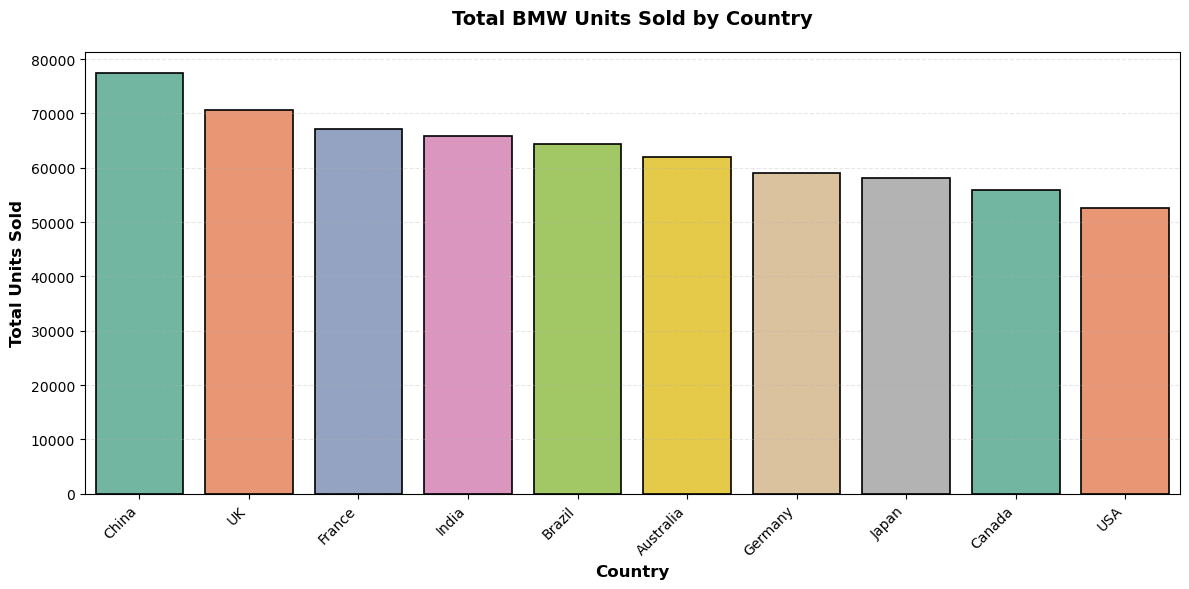

In [196]:
# Visualize total units sold by country with professional styling
plt.figure(figsize=(12, 6))

# Create barplot with attractive color palette
sns.barplot(
    x=df.groupby('country')['units_sold'].sum().sort_values(ascending=False).index,
    y=df.groupby('country')['units_sold'].sum().sort_values(ascending=False).values,
    palette="Set2",  # Clean pastel color palette
    edgecolor="black",  # Add black borders for definition
    linewidth=1.2
)

plt.title("Total BMW Units Sold by Country", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Country", fontsize=12, fontweight='bold')
plt.ylabel("Total Units Sold", fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')  # Subtle gridlines for readability

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The bar chart shows that China has the highest total units sold, followed by the UK and France. Sales then gradually decline across the remaining countries, with the USA recording the lowest total units sold among those shown. The differences between countries are noticeable but not extreme, suggesting relatively comparable sales volumes overall. This indicates stronger market performance in China and parts of Europe, while North America, particularly the USA, appears to have lower overall sales in comparison.

C:\Users\Shahir Wakili\AppData\Local\Temp\ipykernel_21936\617745219.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


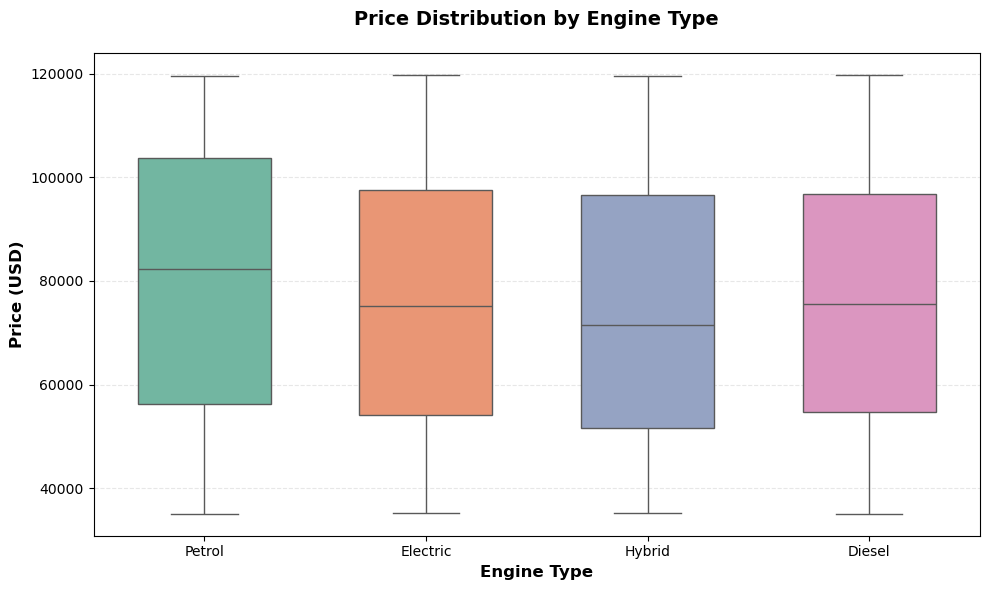

In [192]:
# Create a clean, professional boxplot showing price distribution by engine type
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="engine_type",
    y="price_usd",
    palette="Set2",  # Clean pastel color palette
    width=0.6  # Slightly narrower boxes for cleaner look
)

plt.title("Price Distribution by Engine Type", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Engine Type", fontsize=12, fontweight='bold')
plt.ylabel("Price (USD)", fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')  # Add subtle gridlines for readability

plt.tight_layout()
plt.show()

The boxplot shows the distribution of vehicle prices across different engine types. Petrol vehicles have the highest median price, while Hybrid vehicles appear to have the lowest median among the four categories. Electric and Diesel vehicles have similar median prices, sitting between Petrol and Hybrid. The overall price ranges are fairly similar across all engine types, with considerable overlap in their distributions. This suggests that while there are slight differences in typical pricing by engine type, no category is dramatically more expensive or cheaper than the others.

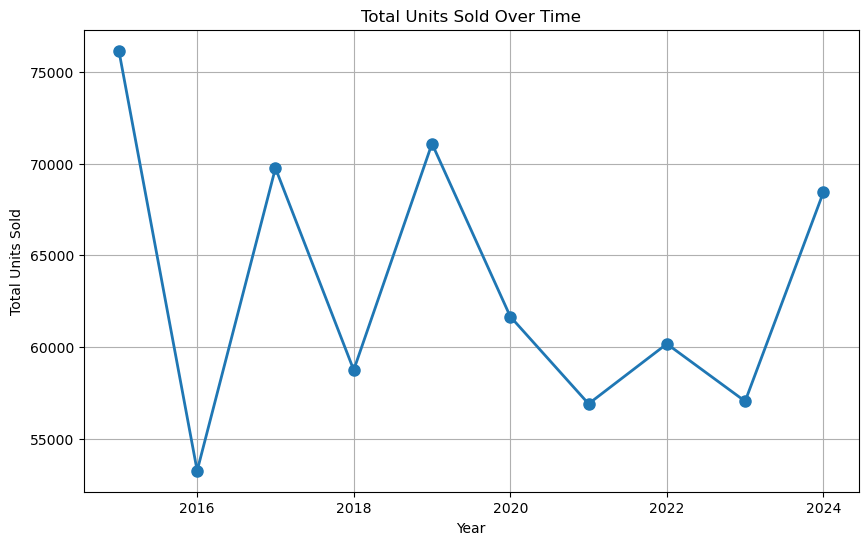

In [248]:
#plt.plot(df["year"], df["units_sold"])
# Aggregate by a grouping variable



plt.figure(figsize=(10, 6))
plt.plot(df.groupby('year')['units_sold'].sum().index, df.groupby('year')['units_sold'].sum().values, marker='o', linewidth=2, markersize=8)
plt.title('Total Units Sold Over Time')
plt.xlabel('Year') 
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.show()



The line chart shows that total units sold fluctuate over time rather than following a steady upward or downward trend. Sales were highest around 2015, dropped significantly in 2016, then recovered in 2017 and 2019. After 2019, sales declined again before rising in 2024. Overall, the pattern suggests cyclical movement with noticeable ups and downs rather than consistent growth. This indicates that external factors may be influencing sales performance across different years.

## 2️⃣ DATA PREPROCESSING & CLEANING

### Select Relevant Features
Keep only the columns needed for analysis and drop irrelevant features

In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   object 
 3   model                  1000 non-null   object 
 4   segment                1000 non-null   object 
 5   engine_type            1000 non-null   object 
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), object(4)
memory usage: 109.5+ K

In [ ]:
#Cleaning data by checking for duplicates and null values
df.isnull().sum() 
df.duplicated().sum()


In [251]:
df = df.filter(['year', 'model', 'country', 'dealership_count', 'segment', 'engine_type', 'price_usd', 'marketing_spend_usd', 'units_sold'])

In [ ]:
# Convert categorical columns to 'category'
print("Converting categorical columns...")
df['country'] = df['country'].astype('category')
df['model'] = df['model'].astype('category')
df['segment'] = df['segment'].astype('category') 
df['engine_type'] = df['engine_type'].astype('category')

In [252]:
# Remove constant columns (columns with only one unique value - no variance)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
df = df.drop(columns=constant_cols)
df

,year,model,country,dealership_count,segment,engine_type,price_usd,marketing_spend_usd,units_sold
0,2021,X1,Australia,96,SUV,Petrol,82234,315372,324
1,2018,i4,Australia,234,Sedan,Electric,82291,447798,556
2,2022,5 Series,USA,25,Electric,Hybrid,40594,259755,152
3,2019,i7,Australia,319,SUV,Electric,42371,323541,730
4,2021,X5,Brazil,367,SUV,Diesel,82315,482015,1156
...,...,...,...,...,...,...,...,...,...
995,2024,i4,UK,177,Sedan,Electric,64813,126425,570
996,2024,3 Series,India,56,Sedan,Petrol,119431,473502,433
997,2022,5 Series,Brazil,212,SUV,Electric,100679,65994,614
998,2016,i7,Brazil,223,Sedan,Hybrid,45681,161915,511


In [253]:
df.corr(numeric_only=True)["units_sold"].sort_values(ascending=False)


units_sold             1.000000
dealership_count       0.868554
marketing_spend_usd    0.045648
year                  -0.026098
price_usd             -0.073839
Name: units_sold, dtype: float64

Units sold has a strong positive correlation with dealership count (0.87), suggesting that an increase in the number of dealerships is closely associated with higher sales. In contrast, marketing spend, year, and price show very weak correlations with units sold, indicating they have limited linear relationship with sales in this dataset.

In [168]:
# Check unique values per column (identify categorical vs continuous)
df.nunique()


year                    10
model                   10
country                 10
dealership_count       355
segment                  3
engine_type              4
price_usd              994
marketing_spend_usd    996
units_sold             621
dtype: int64

## 3️⃣ COLLINEARITY & CORRELATION ANALYSIS

### Correlation Matrix Heatmap
Visualize pairwise correlations between numeric variables.
Look for high correlations (|r| > 0.7) which may indicate collinearity.

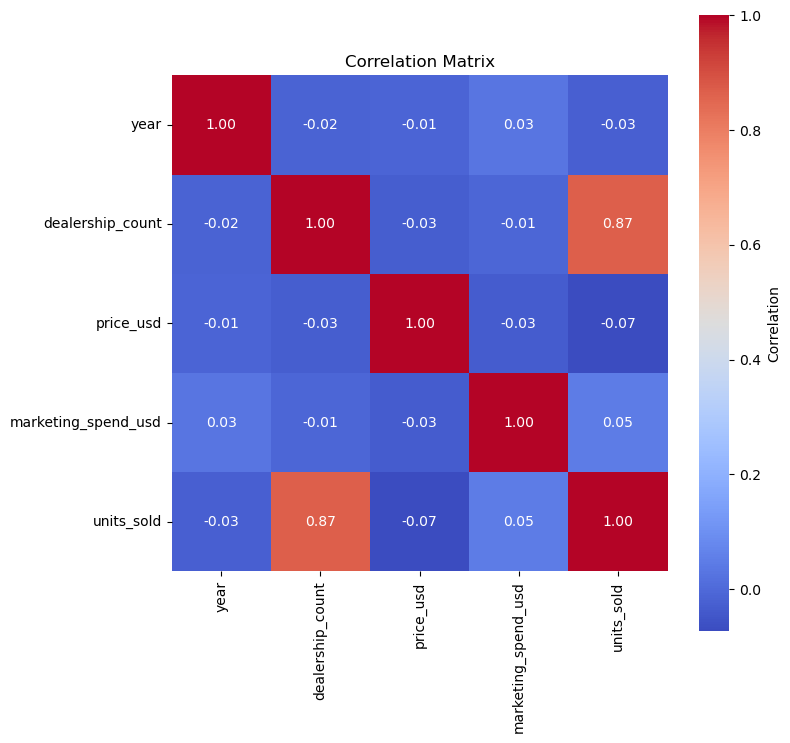

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar=True,                     # show colour bar
    cbar_kws={"label": "Correlation"}  # label it
)

plt.title("Correlation Matrix")
plt.show()

The matrix shows that dealership_count has a very strong positive correlation (0.87) with units_sold, meaning as the number of dealerships increases, units sold also increases significantly. In contrast, price_usd (-0.07), marketing_spend_usd (0.05), and year (-0.03) have very weak correlations with units_sold, suggesting they have little direct linear relationship with sales in this dataset. This indicates that dealership_count is likely the main driver of units sold, while the other variables may not meaningfully explain variation in sales. Overall, the model’s weak performance makes sense because most predictors have minimal correlation with the response variable.


## 4️⃣ MODEL BUILDING & REGRESSION ANALYSIS

### Set Up Train/Test Data
Prepare features and target variable, perform 80/20 train-test split

In [ ]:
#Training the regression model
X = df[['price_usd']]
y = df['units_sold']
X = pd.get_dummies(X, drop_first=True, dtype=float)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Converting categorical columns...


In [ ]:
# Train simple linear regression model (baseline)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


print("\n✓ Baseline linear regression model trained")

### Build Full OLS Regression Model
Use **statsmodels** to fit a comprehensive regression model with all predictors.
This produces output identical to R's `summary(lm())` function.

In [257]:
import statsmodels.formula.api as smf

# Fit the full model with all predictors
model = smf.ols("""
units_sold ~ price_usd
+ marketing_spend_usd
+ C(country)
+ C(model)
+ C(segment)
+ C(engine_type)
""", data=df).fit()

# Display full regression summary (just like R's summary())
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.337
Date:                Sat, 21 Feb 2026   Prob (F-statistic):              0.125
Time:                        14:49:18   Log-Likelihood:                -6975.0
No. Observations:                1000   AIC:                         1.400e+04
Df Residuals:                     974   BIC:                         1.413e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The regression results indicate that the model is not statistically significant overall, as the F-statistic p-value (0.125) is greater than the 0.05 significance level. The R-squared value of 0.033 and adjusted R-squared of 0.008 show that the model explains only a very small proportion of the variation in units sold. Additionally, most of the predictor variables have p-values above 0.05, meaning they are not statistically significant contributors to explaining sales. While the intercept is statistically significant, this only represents the baseline sales level and does not indicate meaningful explanatory power. Overall, there is insufficient statistical evidence to conclude that the predictors significantly impact units sold.

### Calculate Performance Metrics
Compute **R²**, **RMSE**, **MAE**, and **MSE** on test set to evaluate model fit

In [259]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Predictions on test set (formula model requires all formula columns in a DataFrame)
x_test_formula = df.loc[x_test.index, [
	"price_usd",
	"marketing_spend_usd",
	"country",
	"model",
	"segment",
	"engine_type"
]].copy()

y_pred = model.predict(x_test_formula)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*70)
print("MODEL PERFORMANCE METRICS")
print("="*70)
print(f"R² Score:           {r2:.4f}  (0-1, higher is better)")
print(f"RMSE:               {rmse:.2f}  (units sold)")
print(f"MAE:                {mae:.2f}  (units sold)")
print(f"MSE:                {mse:.2f}")

MODEL PERFORMANCE METRICS
R² Score:           0.0251  (0-1, higher is better)
RMSE:               258.15  (units sold)
MAE:                215.03  (units sold)
MSE:                66640.70


The model performance metrics indicate weak predictive ability. The R² score of 0.025 suggests that the model explains only about 2.5% of the variation in units sold, which is very low. The RMSE of 258.15 and MAE of 215.03 show that predictions are off by roughly 215–258 units on average, which is relatively large given the scale of sales. The high MSE further reflects substantial prediction errors. Overall, these metrics confirm that the model does not perform well and has limited explanatory and predictive power.


### Visualize Model Predictions
Create plots to assess model fit and check if residuals are randomly distributed

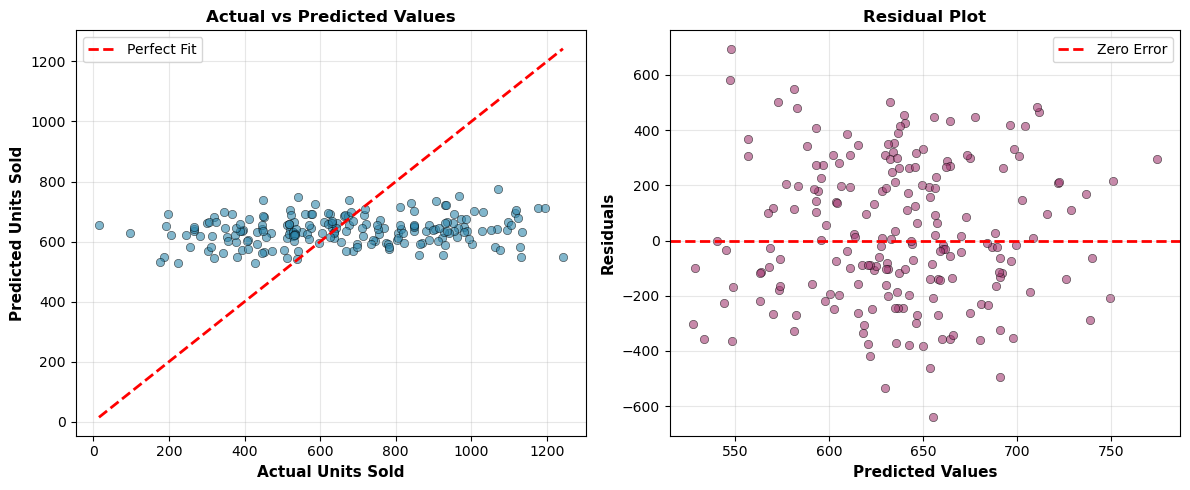

In [258]:
# Create side-by-side plots to assess model fit
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='#2E86AB', edgecolor='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Units Sold', fontsize=11, fontweight='bold')
plt.ylabel('Predicted Units Sold', fontsize=11, fontweight='bold')
plt.title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6, color='#A23B72', edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error')
plt.xlabel('Predicted Values', fontsize=11, fontweight='bold')
plt.ylabel('Residuals', fontsize=11, fontweight='bold')
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Actual vs Predicted chart shows that predictions are clustered within a narrow range, while the actual values vary much more widely. Ideally, the points would follow the diagonal line closely, but instead they are spread out, indicating weaker accuracy. The residual plot shows points scattered around zero without a clear pattern, suggesting there is no consistent bias. However, the spread of the residuals is quite large, meaning predictions often differ substantially from actual values. Overall, the model assumption is not met and relation seems very weak sales.

The Actual vs Predicted chart shows that predictions are clustered within a narrow range, while the actual values vary much more widely. Ideally, the points would follow the diagonal line closely, but instead they are spread out, indicating weaker accuracy. The residual plot shows points scattered around zero without a clear pattern, suggesting there is no consistent bias. However, the spread of the residuals is quite large, meaning predictions often differ substantially from actual values. Overall, the model assumption is not met and relation seems very weak sales.

In [244]:
print("\n" + "="*70)
print("FINAL MODEL SUMMARY")
print("="*70)
print(f"Training samples:   {len(x_train)}")
print(f"Testing samples:    {len(x_test)}")
print(f"R² (Test):          {r2:.4f}")
print(f"RMSE (Test):        {rmse:.2f} units")
print(f"\nInterpretation:")
print(f"- The model explains {r2*100:.2f}% of variance in units sold")
print(f"- Average prediction error: ±{mae:.2f} units")
print("="*70)


FINAL MODEL SUMMARY
Training samples:   800
Testing samples:    200
R² (Test):          0.0251
RMSE (Test):        258.15 units

Interpretation:
- The model explains 2.51% of variance in units sold
- Average prediction error: ±215.03 units


Overall, the model demonstrates weak predictive performance, explaining only a minimal proportion of the variation in units sold and producing substantial prediction errors. The low R² and high error metrics indicate that the current set of predictors does not meaningfully explain sales outcomes. While the regression assumptions appear broadly satisfied, the model lacks explanatory power and practical forecasting value. This suggests that key drivers of sales are either missing from the dataset or that alternative modelling approaches may be required to better capture sales behaviour.